# Practical 6 (Bonus): Linear Regression

**Course:** WBCS032-05 Introduction to Machine Learning  
**Student Names:**  Winand Metz, Matthias Nijman  
**Student Numbers:**  S6417221, S4667999  

---

## Assignment Overview

In this assignment, you will implement linear regression as introduced and discussed in class, assuming an underlying dependence of the form $y = \mathbf{w} \cdot \mathbf{x}$ with $\mathbf{w}\in I\!\!R^{25}$.


You will work with the files `xtrain.csv`, `ytrain.csv`, `xtest.csv`, and `ytest.csv` with the data. These files contain two sets of 500 25-dimensional feature vectors and two sets of 500 continuous target labels.

## 1. Introduction (1 point)

Describe the goal of this assignment.

**Your answer here:**

The goal of this assignment is to implement and train a linear regression model, where variable $y$ is assumed to be linearly dependend on feature vector $x$. Experimentation is done through taking the first $P$ vectors and values from the provided `xtrain.csv` and `ytrain.csv` datasets, which contain the related $x$ and $y$ respectively, to then train and evaluate feature weights. The  `xtest.csv` and `ytest.csv` are then used to eveluate the model accuracy.

## 2. Methods (3 points)

### 2.1 Explain Linear Regression (0.5 points)

Explain the algorithm in a general manner.

**Your answer here:**  

As a supervised algorithm, it models a dependent variable $y$ as a function of some independent variable(s) $x_i$. It does so by finding a line or surface that best fits the data and codifies this in it's weights.

### 2.2 Implementation (2.5 points)

You need to implement the linear regression **yourself**. Both the code quality and correctness will be graded.

*__Note:__* **Do not change the cell labels! Themis will use them to automatically grade your submission.**

In [216]:
# Load required libraries

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

xtrain_path = 'xtrain.csv'
ytrain_path = 'ytrain.csv'
xtest_path  = 'xtest.csv'
ytest_path  = 'ytest.csv'

In [217]:
# Read the file containing the data

xtrain = np.array(pd.read_csv(xtrain_path, header=None))
ytrain = np.array(pd.read_csv(ytrain_path, header=None)).flatten()
xtest  = np.array(pd.read_csv(xtest_path,  header=None))
ytest  = np.array(pd.read_csv(ytest_path,  header=None)).flatten()

p_values = [30, 40, 50, 75, 100, 200, 300, 400, 500]

Implement linear regression in order to determine an estimate $\mathbf{w}^*$ from the first $P$ feature vectors and corresponding labels in the set `xtrain` and `ytrain`, respectively. To this end, construct the pseudoinverse solution discussed in class, which minimizes the Mean Squared Error (MSE):

$$ 
E_{train} =  \frac{1}{P}  
\sum_{\mu=1}^P \, \frac{1}{2} \Big( \mathbf{w}^* \cdot \mathbf{x}_{train}^\mu - y_{train}^\mu \Big)^2.
$$

You can use available built-in functions or available code for the pseudoinverse (e.g. Python: `numpy.linalg.pinv`) but make sure that the matrix and vector dimensions are correct and that you obtain $\mathbf{w}^* \in I\!\!R^{25}.$  Unlike on the lecture slides we normalize the MSE here by $P$. This does not  matter for the actual optimization, but  makes the resulting MSE comparable for training sets with different $P$ and the test error (see below).

With the resulting vector of parameters, also determine the corresponding test error

$$ 
E_{test} =  \frac{1}{1000}
\sum_{\mu=1}^{500} \, \left( \mathbf{w}^* \cdot \mathbf{x}_{test}^\mu - y_{test}^\mu \right)^2
$$

which is always computed w.r.t. all of the $500$ samples in the test data set.

In [218]:
def linear_regression(data_x, data_y):
    '''
    Linear regression

    Args:
        data_x (ndarray): Data points.
        data_y (ndarray): output values

    Returns:
        w_star (ndarray): optimal parameters
    '''
    return np.linalg.pinv(data_x) @ data_y

In [219]:
def MSE(data_x, data_y, w_star):
    '''
    Compute the MSE error

    Args:
        data_x (ndarray): Data points.
        data_y (ndarray): output values
        w_star (ndarray): the weights of linear regression

    Returns:
        error (float): the MSE error
    '''
    return 1/2 * 1/len(data_x) * np.sum([np.square(w_star @ data_x[i] - data_y[i]) for i in range(len(data_x))])

In [220]:
for p in [30, 100, 500]:
    w = linear_regression(xtrain[:p], ytrain[:p])
    print(round(float(MSE(xtrain[:p], ytrain[:p], w)), 6))
    print(round(float(MSE(xtest, ytest, w)), 6))

0.040308
6.36873
0.349136
0.663851
0.485495
0.531614


## 3. Experimental Results (3 points)

### 3.1 Estimated weights

*__Note:__* This section **is graded** by Themis.

Implement the function below to generate bar graphs of the estimated parameter vector $\mathbf{w}^*$ for varying training set sizes $P$. The $x$-axis should correspond to the $25$ component indices and the $y$-axis should display the component $w^*_j$.

In [221]:
def plot_weights(xtrain, ytrain, p):
    """
    Plot the estimated parameter vector w* as a bar graph for a given training set size P.

    Args:
        xtrain (ndarray): Training feature vectors.
        ytrain (ndarray): Training labels.
        p (int): Number of training samples to use.
    """
    w_star = linear_regression(xtrain[:p], ytrain[:p])

    plt.bar(range(1, len(w_star) + 1), w_star)
    plt.title(f'Estimated Parameter Vector $w^*$ for P = {p}')
    plt.xlabel('Component Index (j)')
    plt.ylabel('$w^*_j$')

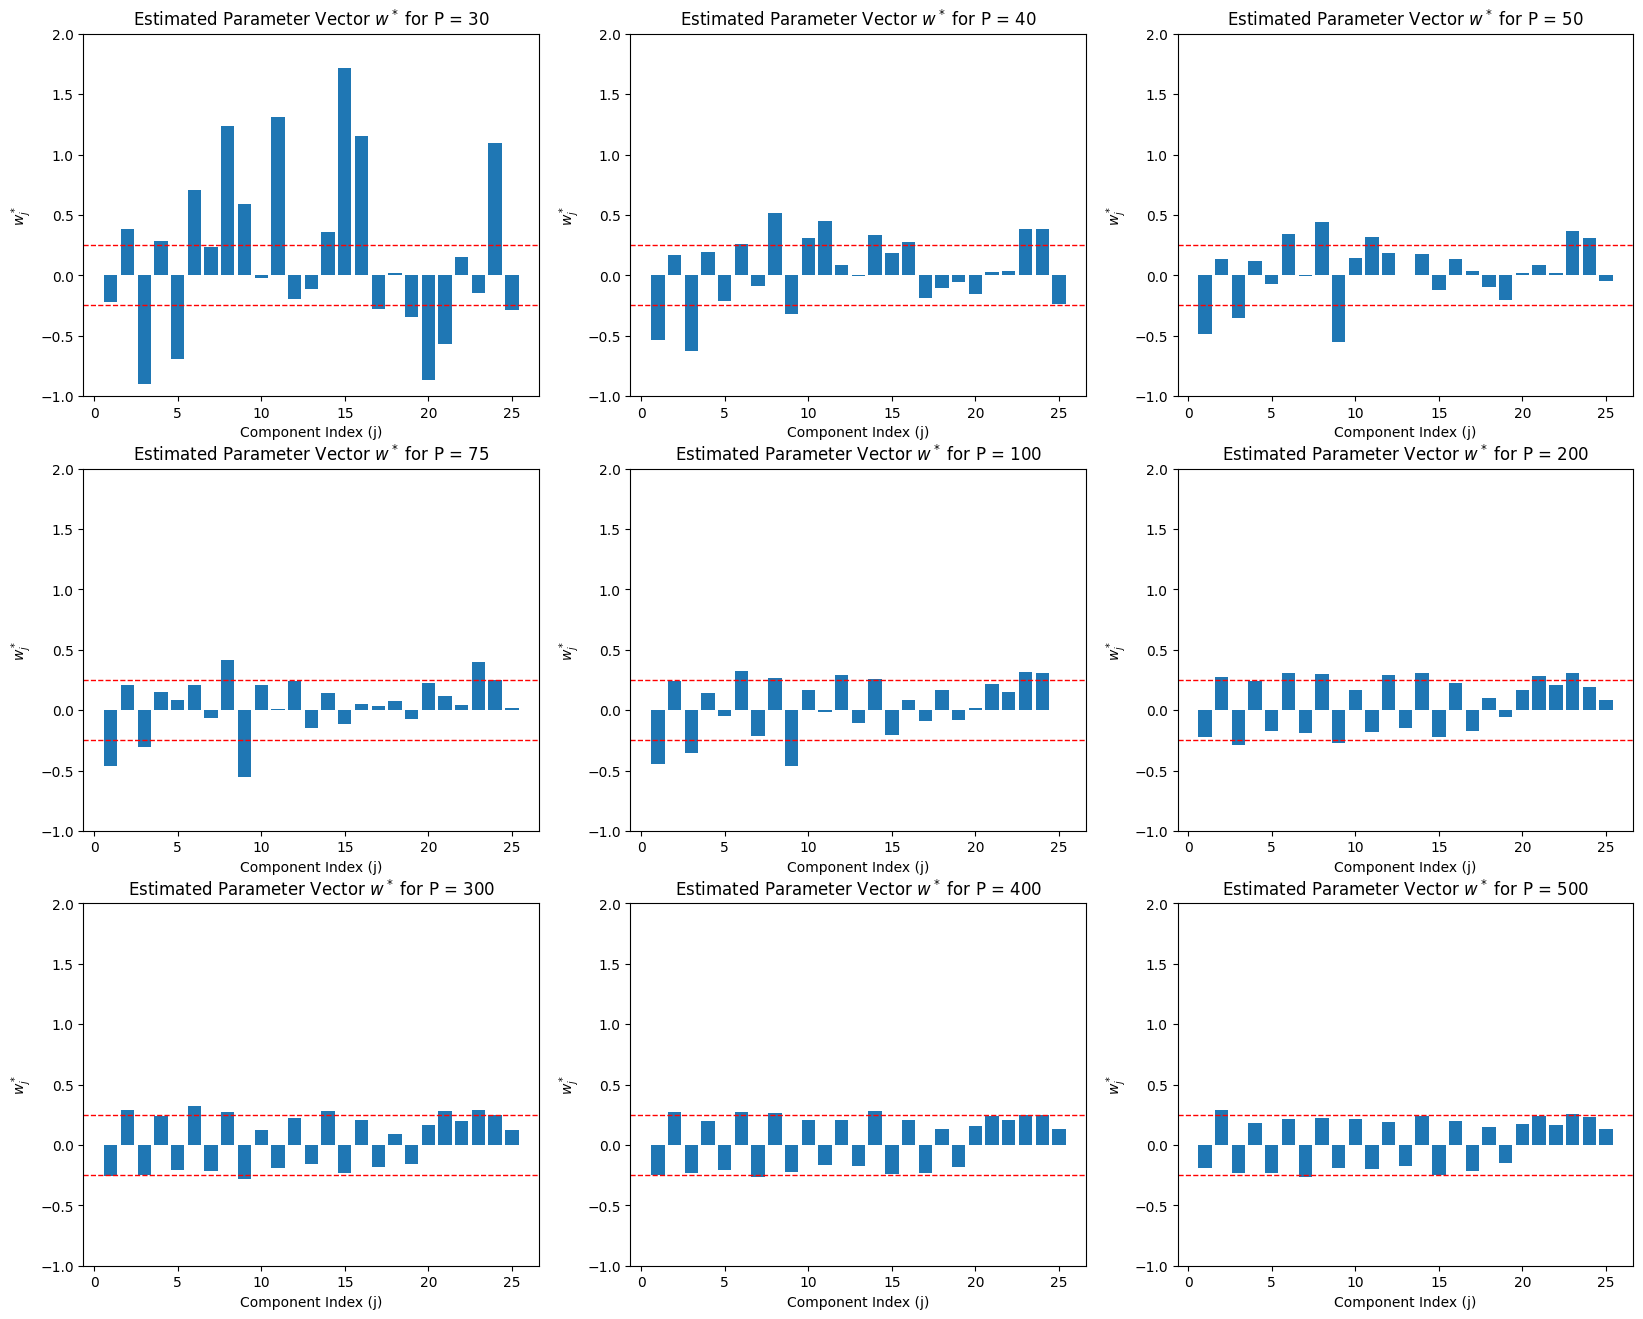

In [222]:
plt.figure(figsize=(20, 16))

for i in range(len(p_values)):
    plt.subplot(3, 3, i+1)
    plot_weights(xtrain, ytrain, p_values[i])
    plt.ylim(-1, 2)
    plt.axhline(0.25, lw=1, linestyle='--', c='red')
    plt.axhline(-0.25, lw=1, linestyle='--', c='red')

### 3.2 Train and test error

*__Note:__* This section **is graded** by Themis.

Implement the function below to display both $E_{train}$ and $E_{test}$ for the following training set sizes: $P = 30, 40, 50, 75, 100, 200, 300, 400, 500$.

In [223]:
def plot_train_test_errors(xtrain, ytrain, xtest, ytest, p_values):
    """
    Plot training and test MSE errors vs training set size.

    Args:
        xtrain (ndarray): Training feature vectors.
        ytrain (ndarray): Training labels.
        xtest (ndarray): Test feature vectors.
        ytest (ndarray): Test labels.
        p_values (list): List of training set sizes to evaluate.
    """
    train_mse = [MSE(xtrain[:p], ytrain[:p], linear_regression(xtrain[:p], ytrain[:p])) for p in p_values]
    test_mse = [MSE(xtest, ytest, linear_regression(xtrain[:p], ytrain[:p])) for p in p_values]

    plt.plot(p_values, train_mse, marker = 'o', c='blue')
    plt.plot(p_values, test_mse, marker = 'o', c='red')
    plt.title('Training and Test Errors vs. Training Set Size')
    plt.xlabel('Training Set Size (P)')
    plt.ylabel('Mean Squared Error')
    plt.legend(['Training Error', 'Test Error'])
    plt.show()

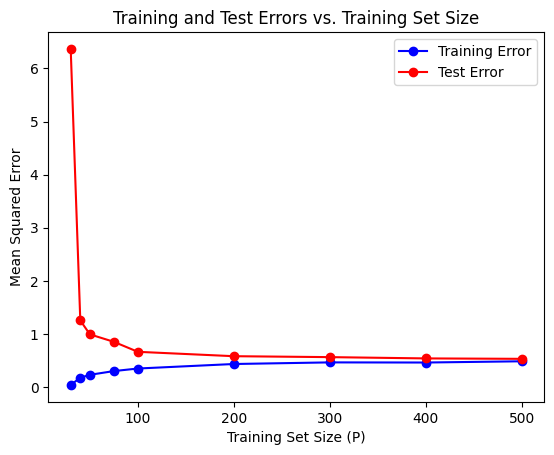

In [224]:
plot_train_test_errors(xtrain, ytrain, xtest, ytest, p_values)

Can you guess what the true vector $\mathbf{w}$ was that generated the data?

**Your answer here:**  

Our best guess for the true vector $\mathbf{w}$ is the vector $\mathbf{w}^*$ for $P=500$. This is backed by the MSE plot, where the lowest test error is made by $P=500$. The corresponding weight plot shows values flipping between 0.25 and -0.25, and after the 20th component index the weights stay positive. 

## 4. Discussion (2 points)

Discuss your observations on the obtained results.

**Your answer here:**

## Contribution

State your individual contribution.

**Your answer here:**  

We worked with pair-programming and we have contributed equally to the assignment.